<a href="https://colab.research.google.com/github/Erjg1012/Procesamiento-de-Lenguaje-Natural-PLN-/blob/main/Clasificaci%C3%B3n_de_comentarios_de_hu%C3%A9spedes_en_plataformas_de_alojamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ##Clasificación de comentarios de huéspedes en plataformas de alojamiento (Airbnb)


### Objetivo:
Desarrollar un sistema de procesamiento de lenguaje natural que analice
comentarios de usuarios en plataformas de alojamiento temporal (como Airbnb) para clasificar automáticamente las opiniones en positivas, negativas o neutras. Este sistema permitirá obtener insights sobre la calidad del servicio, limpieza, ubicación, atención del anfitrión, entre otros aspectos relevantes, a partir de reseñas escritas por los huéspedes.

Comenzamos cargando las librerias.

In [ ]:
!pip install spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 24.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install transformers

In [ ]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from collections import Counter
import matplotlib.gridspec as gridspec
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from spellchecker import SpellChecker

In [ ]:
# Descargar recursos necesarios
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 1. Recolección de datos:

a) Utilizar datasets públicos de comentarios de Airbnb disponibles en plataformas como Inside Airbnb, Kaggle u otros repositorios.

b) Extraer campos clave como el comentario del huésped, puntuación del
alojamiento, fecha, ubicación, tipo de alojamiento, duración de la estancia entre otras variables que nos ayuden a a la clasificación.

In [ ]:
df = pd.read_excel('Alcaldia_MiguelHIDALGO.xlsx', )
df.head()

,Nombre,Apellido Materno,Apellido Paterno,Telefono,Correo,Nombre.1,Nombre.2,Colonia,Departamento,Recamaras,...,Asador,Jardin privado,Terraza,Seguridad Privada,Antigüedad,Fecha de publicación,Servicios Basicos,Area Infantil,Area Deportiva,Caseta de Guardia
0,Luis,López,García,5598252194,luis41@gmail.com,Sofía,Andrea,San Miguel Chapultepec II Sección,123,4,...,No,Sí,Sí,Sí,Hasta 5 años,Desde ayer,Electricidad,Sí,Sí,Sí
1,Andrea,Hernández,Hernández,5544140320,juan64@gmail.com,José,Sofía,Anáhuac I Sección,80,1,...,Sí,Sí,Sí,No,A estrenar,Última semana,"Cable, Teléfono, Electricidad",No,No,Sí
2,José,Martínez,Hernández,5595739477,juan22@gmail.com,María,Andrea,Lomas de Sotelo,113,5,...,No,No,Sí,Sí,A estrenar,Desde ayer,"Electricidad, Gas",No,No,Sí
3,María,Ramírez,Sánchez,5511372263,juan40@hotmail.com,Andrea,Lucía,Lomas de Chapultepec V Sección,70,2,...,Sí,No,No,No,A estrenar,Desde ayer,Agua,Sí,Sí,No
4,Andrea,Flores,Flores,5538091541,miguel11@yahoo.com,Miguel,José,Lomas de Sotelo,32,1,...,Sí,Sí,No,Sí,Hasta 5 años,Desde ayer,Gas,No,No,Sí


### 2. Limpieza, Tokenización y Normalización:

Para empezar tendríamos que hacer un análisis exploratorio de los datos para poder observar y analizar qué tipos de datos tenemos y la forma en la cual nosotros podamos hacer una limpieza adecuada y pertinente, una posible propuesta de limpieza seria:

a) Conversión del texto a minúsculas, eliminación de signos de puntuación, caracteres especiales, emojis, y en caso de que se detecte algunos problemas de ortografía poderlos corregirlos.

b) Eliminación de stopwords en español e inglés, si aplica, dependiendo del idioma del corpus.

c) Tokenización y lematización usando herramientas como SpaCy o NLTK,
adaptadas al dominio del lenguaje de los usuarios.

In [ ]:
def analisis_exploratorio(df, columna):
    print("\nResumen inicial:")
    print(df[columna].describe())
    print("\nValores nulos:", df[columna].isnull().sum())

analisis_exploratorio(df, 'Recomendación')


Resumen inicial:
count                                                 10101
unique                                                   15
top       Excelente por la vista, la alberca genial para...
freq                                                    674
Name: Recomendación, dtype: object

Valores nulos: 0


In [ ]:
df['Recomendación'].head()

,Recomendación
0,"Excelente por la vista, la alberca genial para..."
1,"La vista es increíble, pero la habitación podr..."
2,"muy buena ubicación, pero el servicio podría m..."
3,"Un lugar perfecto si te gusta la tranquilidad,..."
4,"Muy buena ubicación, pero el servicio podría m..."


In [ ]:
df['Recomendación'].count()

np.int64(10101)

Como se puede observar contamos con 10,101 comentarios de las zonas de Miguel Hidalgo.

In [ ]:
# -----------------------------------------------------------
# LIMPIEZA DE DATOS
# -----------------------------------------------------------

def limpiar_texto_suave(texto):
    """Limpieza básica preservando más contenido"""
    if pd.isna(texto):
        return ""

    # Convertir a minúsculas y eliminar URLs/menciones
    texto = re.sub(r"http\S+|www\S+|@\S+", '', str(texto))
    # Mantener signos de puntuación básicos (¡importante para análisis de sentimiento!)
    texto = re.sub(r"[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s.,!?¿¡]", '', texto)
    return texto.lower().strip()

def eliminar_stopwords_suave(texto):
    """Filtrado más conservador de stopwords"""
    if not texto:
        return ""

    stop_words = set(stopwords.words('spanish'))
    # Mantener palabras de 2 caracteres que pueden ser importantes
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return ' '.join(palabras)

def limpieza_texto(df, columna_texto):
    """Limpieza que preserva más datos con lematización"""
    print("Iniciando limpieza con lematización...")
    print(f"Registros originales: {len(df)}")

    df_clean = df.copy()

    # Aplicar limpieza básica
    df_clean['texto_limpio'] = df_clean[columna_texto].apply(limpiar_texto_suave)
    df_clean['texto_limpio'] = df_clean['texto_limpio'].apply(eliminar_stopwords_suave)

    # Lematización: Aplicar la lematización después de la limpieza básica y eliminación de stopwords
    df_clean['texto_limpio'] = df_clean['texto_limpio'].apply(lematizar_texto)  # Aquí es donde aplicas la lematización

    # Eliminar registros vacíos
    vacios = df_clean['texto_limpio'].str.strip() == ''
    print(f"Registros vacíos eliminados: {vacios.sum()}")
    df_clean = df_clean[~vacios]

    print(f"Registros finales para análisis: {len(df_clean)}")
    print("Limpieza completada!")
    return df_clean

df_clean = limpieza_texto(df, 'Recomendación')  # Usa todo el dataset

Iniciando limpieza con lematización...
Registros originales: 10101
Registros vacíos eliminados: 0
Registros finales para análisis: 10101
Limpieza completada!


### 3. Representación de texto:

a) Para que los modelos de aprendizaje automático puedan procesar los
comentarios de los usuarios, primero hay que convertirlos a vectores numéricos. Una forma en que podamos realizarlo es usando TF-IDF, ya que mide qué tanimportante es una palabra en un comentario comparado con todos los demás.
También podríamos usar embeddings como Word2Vec o GloVe, para representarpalabras como vectores densos que capturan similitudes de significado. Y para una comprensión más profunda del contexto, podríamos aplicar modelos preentrenados como BERT, que generan vectores dinámicos según el uso de la palabra en su frase.

b) Posteriormente pasaremos a la reducción de dimensionalidad dado a que si usamos muchas palabras o embeddings largos, el número de dimensiones puede ser muy alto, lo cual complica el análisis y podría hacer lento el entrenamiento. Por eso, se pueden aplicar técnicas como PCA o t-SNE para reducir dimensiones. Esto también permite visualizar los datos en 2D o 3D, por ejemplo, mostrando si los comentarios positivos y negativos forman grupos separados.

In [ ]:
# -----------------------------------------------------------
# EMBEDDINGS
# -----------------------------------------------------------

def generar_embeddings_sbert(textos):
    print("\nCargando modelo SBERT...")
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    print("Generando embeddings...")
    embeddings = model.encode(textos, show_progress_bar=True, batch_size=32)
    print(f"Embeddings generados: {embeddings.shape}")
    return embeddings

# Extraer bigramas y trigramas del texto limpio
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=50)
X_ngrams = vectorizer.fit_transform(df_clean['texto_limpio'])
ngrams = vectorizer.get_feature_names_out()

print("\nEjemplos de bigramas/trigramas más frecuentes:")
print(ngrams[:20])

embeddings = generar_embeddings_sbert(df_clean['texto_limpio'].tolist())


Ejemplos de bigramas/trigramas más frecuentes:
['alberca genial' 'alberca genial pasar' 'amplio oscuro' 'baño limpio'
 'bonito pequeño' 'conexión internet' 'conexión internet lento'
 'descansar baño' 'descansar baño limpio' 'descansar conexión'
 'descansar conexión internet' 'excelente luz' 'excelente luz natural'
 'excelente opción' 'excelente opción familia' 'excelente vista'
 'excelente vista alberca' 'familia necesario' 'genial pasar'
 'genial pasar él']

Cargando modelo SBERT...
Generando embeddings...


Batches:   0%|          | 0/316 [00:00<?, ?it/s]

Embeddings generados: (10101, 384)


### 4. Clasificación de sentimientos:

a) Una vez que los comentarios están representados como vectores, se pueden usar clasificadores como Naive Bayes, Regresión Logística o SVM para aprender a distinguir entre opiniones positivas, negativas o neutras.

b) Para saber si el modelo funciona bien, se evaluaria usando métricas como precisión (qué tan correctas son las predicciones positivas), recall (cuántas opiniones positivas reales se detectaron) y F1-score, que combina ambas. Es útil calcular estas métricas para cada clase y no solo fijarse en la exactitud total.

c) Si se cuenta con muchos datos, se pueden usar modelos más potentes como redes neuronales como un MLP que funciona bien con vectores tipo TF-IDF o una LSTM puede procesar directamente el texto en orden, ideal para capturar contexto y emociones más sutiles en las frases. Estos modelos pueden mejorar la clasificación, aunque requieren más recursos.

In [ ]:
print(df.columns)

Index(['Nombre', 'Apellido Materno ', 'Apellido Paterno', 'Telefono', 'Correo',
       'Nombre.1', 'Nombre.2', 'Colonia', 'Departamento', 'Recamaras',
       'Precio', 'Superfie', 'Baños ', 'Estacionamiento', 'Alberca',
       'Centro Comercial', 'Tipo de Renta', 'Precio Renta', 'Recomendación',
       'Acepta Niños', 'Acepta Mascotas', 'Asador', 'Jardin privado',
       'Terraza', 'Seguridad Privada', 'Antigüedad', 'Fecha de publicación',
       'Servicios Basicos', 'Area Infantil', 'Area Deportiva',
       'Caseta de Guardia', 'sentimiento'],
      dtype='object')


In [ ]:
from transformers import pipeline

# Cargar el pipeline de clasificación de sentimientos de Hugging Face
sentiment_pipeline = pipeline('sentiment-analysis')

# Aplicar el análisis de sentimientos en la columna 'Recomendación' y crear la columna 'sentimiento'
df['sentimiento'] = df['Recomendación'].apply(lambda x: sentiment_pipeline(x)[0]['label'])

# Verifica los primeros resultados
print(df[['Recomendación', 'sentimiento']].head())

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


                                       Recomendación sentimiento
0  Excelente por la vista, la alberca genial para...    POSITIVE
1  La vista es increíble, pero la habitación podr...    NEGATIVE
2  muy buena ubicación, pero el servicio podría m...    NEGATIVE
3  Un lugar perfecto si te gusta la tranquilidad,...    POSITIVE
4  Muy buena ubicación, pero el servicio podría m...    NEGATIVE


In [ ]:
# Vectorización con TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)  # Se puede ajustar el número de características
X = vectorizer.fit_transform(df['Recomendación'])  # Los comentarios

# Etiquetas (sentimientos ya asignados por BERT)
y = df['sentimiento']  # 'sentimiento' debe ser la columna con las etiquetas generadas por BERT

# División del conjunto de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = nb.predict(X_test)

# Evaluar el modelo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00      1600
    POSITIVE       1.00      1.00      1.00      1431

    accuracy                           1.00      3031
   macro avg       1.00      1.00      1.00      3031
weighted avg       1.00      1.00      1.00      3031



In [ ]:
# -----------------------------------------------------------
# KMEANS CLUSTERING
# -----------------------------------------------------------

def aplicar_kmeans(embeddings, n_clusters=3):
    print("\nAplicando KMeans...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    from sklearn.metrics import silhouette_score
    if len(set(clusters)) > 1:
        silueta = silhouette_score(embeddings, clusters)
        print(f"Puntuación de silueta: {silueta:.2f}")
    else:
        print("No se pudo calcular puntuación de silueta (solo un cluster)")
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print("\nDistribución de clusters:")
    print(cluster_counts)
    return clusters, kmeans.cluster_centers_

clusters, centroids = aplicar_kmeans(embeddings, n_clusters=5)  # Cambia aquí k si deseas


Aplicando KMeans...
Puntuación de silueta: 0.46

Distribución de clusters:
0    3366
1    1348
2    3367
3     673
4    1347
Name: count, dtype: int64



Evaluando diferentes valores de k...
k=2, Silhouette=0.264
k=3, Silhouette=0.346
k=4, Silhouette=0.418
k=5, Silhouette=0.461
k=6, Silhouette=0.552
k=7, Silhouette=0.613
k=8, Silhouette=0.660


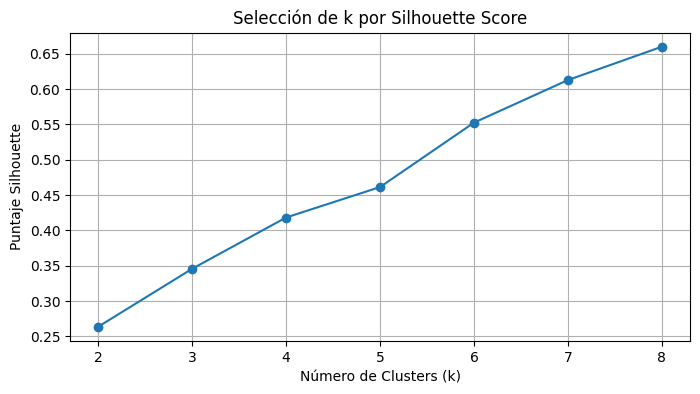

In [ ]:
# -----------------------------------------------------------
# EVALUAR VALORES DE K (opcional)
# -----------------------------------------------------------
from sklearn.metrics import silhouette_score

def evaluar_k(embeddings, rango=(2,10)):
    print("\nEvaluando diferentes valores de k...")
    sil_scores = []
    for k in range(rango[0], rango[1]+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        sil_scores.append(score)
        print(f"k={k}, Silhouette={score:.3f}")

    plt.figure(figsize=(8, 4))
    plt.plot(range(rango[0], rango[1]+1), sil_scores, marker='o')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Puntaje Silhouette')
    plt.title('Selección de k por Silhouette Score')
    plt.grid(True)
    plt.show()


evaluar_k(embeddings, rango=(2,8))

In [ ]:
# -----------------------------------------------------------
# SENTIMIENTO
# -----------------------------------------------------------

def asignar_sentimiento(df, clusters):
    print("\nAsignando sentimientos...")
    palabras_positivas = {
    'excelente', 'recomiendo', 'recomendable', 'genial', 'perfecto', 'contento',
    'satisfecho', 'satisfactorio', 'bueno', 'bonito', 'agradable', 'maravilloso',
    'increíble', 'encanta', 'encantador', 'facil', 'fácil', 'útil', 'cómodo',
    'tranquilo', 'limpio', 'amplia', 'ideal', 'vista', 'vista hermosa', 'relajado',
    'familias', 'amigos', 'tranquilidad', 'bien ubicado', 'todo', 'completo',
    'comodidades', 'alberca', 'rápido', 'acogedor', 'amable', 'positivo',
    'bonita', 'relajante', 'confortable', 'brillante', 'iluminado', 'servicial',
    'disfrutar', 'seguro', 'funciona', 'feliz', 'lugar bonito', 'buena ubicación', 'sí'
    }

    palabras_negativas = {
    'malo', 'pésimo', 'horrible', 'decepción', 'terrible', 'problema', 'falla',
    'error', 'lento', 'deficiente', 'defectuoso', 'decepcionante', 'insatisfecho',
    'descontento', 'inútil', 'devolver', 'caro', 'oscura', 'poca luz', 'frío',
    'sucio', 'ruidoso', 'incompleto', 'olía mal', 'viejo', 'no', 'no recomiendo',
    'esperar', 'demora', 'esperando', 'inestable', 'baja señal', 'baño sucio',
    'conexión lenta', 'internet lento', 'incómodo', 'pequeño', 'estrecho',
    'no sirve', 'problemas', 'desagradable', 'aburrido', 'dañado', 'desorganizado'
    'pero', 'aunque', 'oscura', 'podría', 'baño', 'internet', 'luz',
    'poca luz', 'espera', 'falta', 'no tiene', 'sin', 'lento', 'frío',
    'ruidoso', 'viejo', 'sucio', 'desgastado', 'dañado', 'incompleto',
    'estrecho', 'pequeño', 'incómodo', 'tardado', 'apagado', 'débil',
    'problemas', 'tardanza', 'mal', 'difícil', 'no funcionaba', 'fallando'
    'no me gustó', 'me desagradó', 'hay muchas arañas', 'hay cucarachas', 'estaba sucio',
    'olía mal', 'mal servicio', 'demasiado ruido'
    }

    cluster_sentimientos = {}
    for cluster_id in set(clusters):
        textos_cluster = df[clusters == cluster_id]['texto_limpio']
        todas_palabras = " ".join(textos_cluster).split()
        positivas = sum(1 for palabra in todas_palabras if palabra in palabras_positivas)
        negativas = sum(1 for palabra in todas_palabras if palabra in palabras_negativas)
        total_keywords = positivas + negativas

        if total_keywords == 0:
            sentimiento = "Neutral"
        else:
            ratio_positivo = positivas / total_keywords

            # 🧠 Nueva lógica: mezcla positiva/negativa → depende de quién predomina
            if positivas > 0 and negativas > 0:
                if positivas > negativas * 1.5:
                    sentimiento = "Positivo"
                elif negativas > positivas * 1.5:
                    sentimiento = "Negativo"
                else:
                    sentimiento = "Neutral"
            else:
                if ratio_positivo >= 0.55:
                    sentimiento = "Positivo"
                elif ratio_positivo <= 0.45:
                    sentimiento = "Negativo"
                else:
                    sentimiento = "Neutral"

        cluster_sentimientos[cluster_id] = sentimiento

    # ⬇️ IMPORTANTE: esto devuelve los resultados correctamente
    df['sentimiento'] = [cluster_sentimientos[c] for c in clusters]
    df['cluster'] = clusters

    return df, cluster_sentimientos

df_final, cluster_sentimientos = asignar_sentimiento(df_clean, clusters)


Asignando sentimientos...


### 5. Análisis de resultados e interpretación:

a) Después de entrenar el modelo, se pueden identificar las palabras que más contribuyen a cada tipo de opinión. Por ejemplo, términos como “cómodo”, “tranquilo” o “amable” pueden estar asociados a comentarios positivos, mientras que “sucio”, “ruidoso” o “espera” suelen aparecer en los negativos. Se pueden hacer nubes de palabras o gráficas para visualizar estos resultados.

b) Al combinar la clasificación con otros datos del alojamiento, se pueden generar reportes útiles para detectar patrones. Por ejemplo, se puede saber si cierto tipo de alojamiento tiene más comentarios negativos o si un anfitrión específico tiene mejores reseñas que otros.

c) Analizando los comentarios negativos, se pueden descubrir problemas
frecuentes: mala limpieza, errores de comunicación, ubicación complicada, etc. Esto ayuda a los anfitriones a mejorar la experiencia y permite que Airbnb tome decisiones informadas sobre calidad del servicio.


Generando visualizaciones...


/tmp/ipython-input-55-3295045573.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis', ax=ax1)


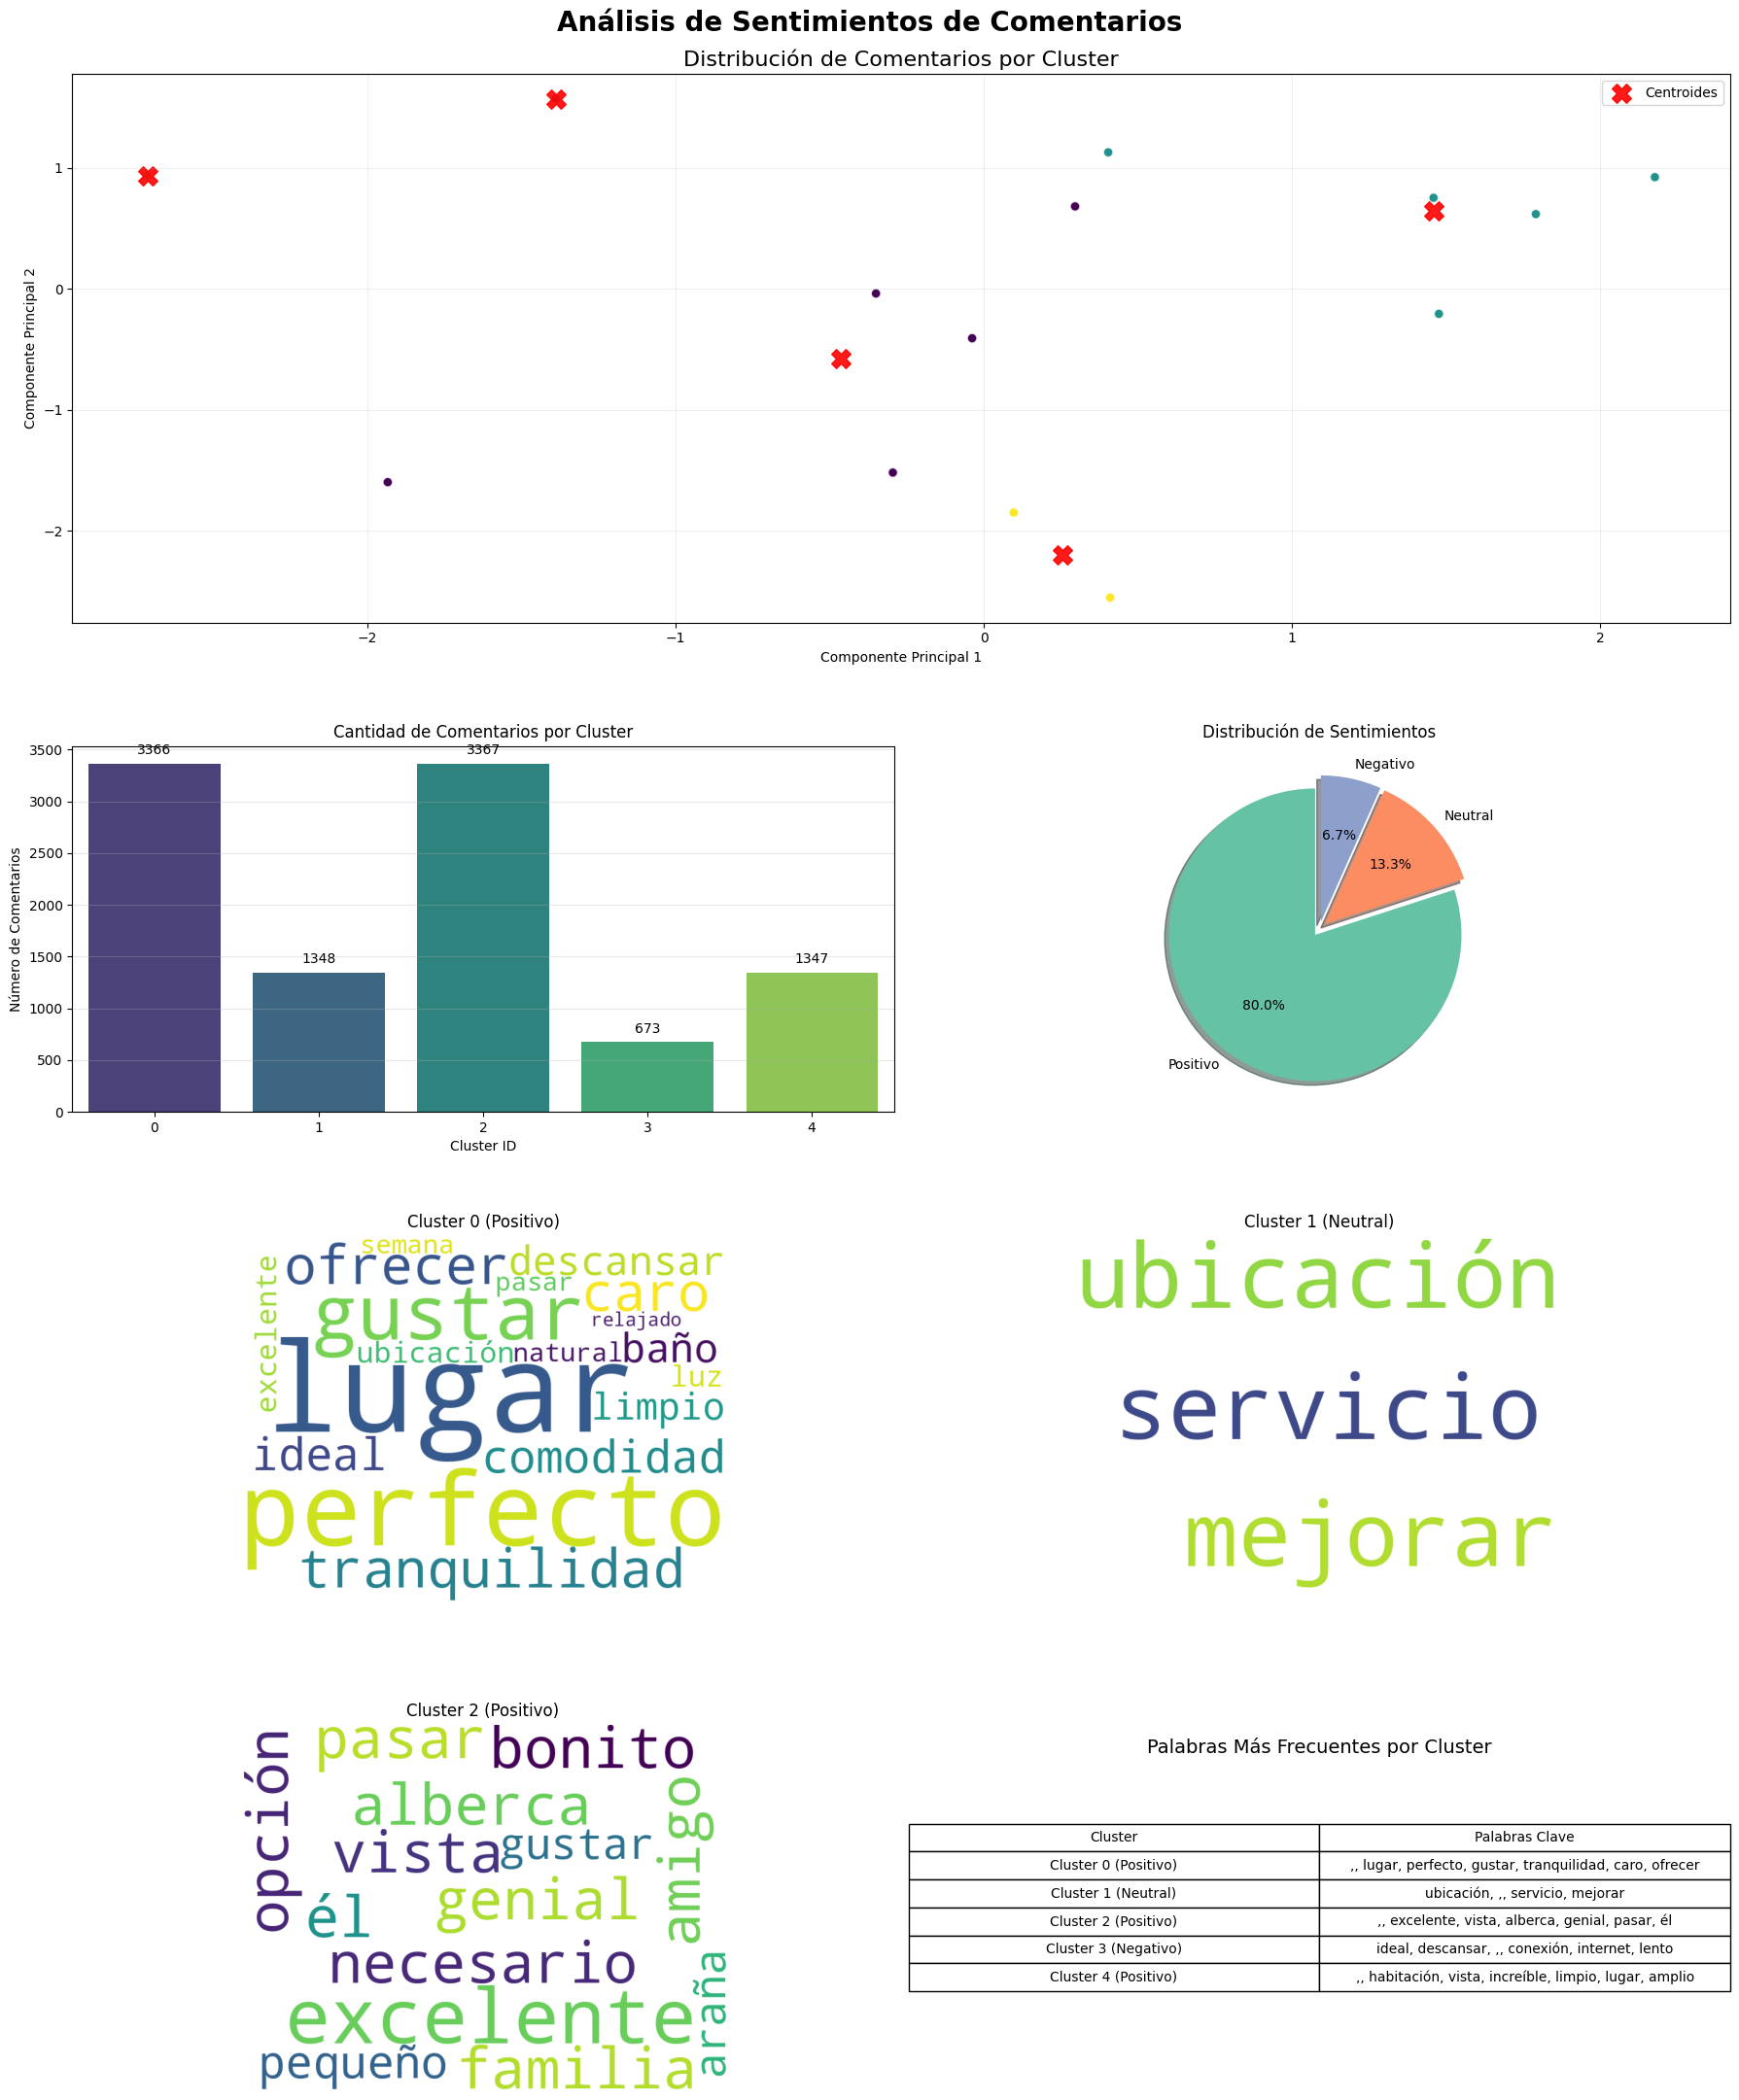

In [ ]:
# -----------------------------------------------------------
# VISUALIZACIÓN
# -----------------------------------------------------------

def visualizar_resultados(df, embeddings, clusters, centroids):
    print("\nGenerando visualizaciones...")
    plt.figure(figsize=(18, 22))
    gs = gridspec.GridSpec(4, 2, height_ratios=[1.5, 1, 1, 1])

    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    ax0 = plt.subplot(gs[0, :])
    scatter = ax0.scatter(
        embeddings_2d[:, 0], embeddings_2d[:, 1],
        c=clusters, cmap='viridis', alpha=0.7, s=50, edgecolor='w'
    )

    centroids_2d = pca.transform(centroids)
    ax0.scatter(
        centroids_2d[:, 0], centroids_2d[:, 1],
        c='red', marker='X', s=200, alpha=0.9, label='Centroides'
    )
    ax0.set_title('Distribución de Comentarios por Cluster', fontsize=16)
    ax0.set_xlabel('Componente Principal 1')
    ax0.set_ylabel('Componente Principal 2')
    ax0.legend()
    ax0.grid(alpha=0.2)

    ax1 = plt.subplot(gs[1, 0])
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis', ax=ax1)
    ax1.set_title('Cantidad de Comentarios por Cluster')
    ax1.set_xlabel('Cluster ID')
    ax1.set_ylabel('Número de Comentarios')
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10), textcoords='offset points')

    ax1.grid(axis='y', alpha=0.3)

    ax2 = plt.subplot(gs[1, 1])
    sentimiento_counts = df['sentimiento'].value_counts()
    colors = ['#66c2a5', '#fc8d62', '#8da0cb']
    ax2.pie(
        sentimiento_counts,
        labels=sentimiento_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        shadow=True,
        explode=(0.05,) * len(sentimiento_counts)
    )
    ax2.set_title('Distribución de Sentimientos')

    wordcloud_axes = [plt.subplot(gs[2, 0]), plt.subplot(gs[2, 1]), plt.subplot(gs[3, 0])]
    unique_clusters = sorted(set(clusters))
    for i, cluster_id in enumerate(unique_clusters):
        if i < len(wordcloud_axes):
            cluster_text = " ".join(df[df['cluster'] == cluster_id]['texto_limpio'])
            wordcloud = WordCloud(
                width=800, height=600, background_color='white',
                colormap='viridis', max_words=100, collocations=False
            ).generate(cluster_text)
            sentimiento = df[df['cluster'] == cluster_id]['sentimiento'].iloc[0]
            wordcloud_axes[i].imshow(wordcloud)
            wordcloud_axes[i].set_title(f'Cluster {cluster_id} ({sentimiento})')
            wordcloud_axes[i].axis('off')

    ax5 = plt.subplot(gs[3, 1])
    ax5.axis('off')
    palabras_table = []
    for cluster_id in unique_clusters:
        cluster_text = " ".join(df[df['cluster'] == cluster_id]['texto_limpio'])
        palabras = cluster_text.split()
        freq_dist = Counter(palabras)
        top_palabras = [word for word, _ in freq_dist.most_common(7)]
        sentimiento = df[df['cluster'] == cluster_id]['sentimiento'].iloc[0]
        palabras_table.append([f'Cluster {cluster_id} ({sentimiento})', ", ".join(top_palabras)])

    tabla = ax5.table(
        cellText=palabras_table,
        colLabels=['Cluster', 'Palabras Clave'],
        loc='center',
        cellLoc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1, 1.5)
    ax5.set_title('Palabras Más Frecuentes por Cluster', fontsize=14, y=0.9)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.3)
    plt.suptitle('Análisis de Sentimientos de Comentarios', fontsize=20, fontweight='bold')
    plt.show()

visualizar_resultados(df_final, embeddings, clusters, centroids)

In [ ]:
print("\n\nMuestras representativas por cluster:")
for cluster_id in sorted(set(clusters)):
    cluster_df = df_final[df_final['cluster'] == cluster_id]
    sentimiento = cluster_sentimientos[cluster_id]
    n_comentarios = len(cluster_df)
    print(f"\n{'═'*50}")
    print(f"CLUSTER {cluster_id} ({sentimiento.upper()}) - {n_comentarios} comentarios")
    print(f"{'═'*50}")
    muestras = cluster_df.sample(min(3, n_comentarios))['Recomendación'].values
    for i, comentario in enumerate(muestras, 1):
        print(f"\nMuestra {i}:\n{comentario}\n")

print("\n" + "═"*70)
print("ANÁLISIS COMPLETADO EXITOSAMENTE".center(70))
print("═"*70)



Muestras representativas por cluster:

══════════════════════════════════════════════════
CLUSTER 0 (POSITIVO) - 3366 comentarios
══════════════════════════════════════════════════

Muestra 1:
Perfecto para pasar un fin de semana relajado


Muestra 2:
La ubicación es excelente, pero no tiene mucha luz natural


Muestra 3:
es bueno, pero no tiene mucho que ofrecer en cuanto a comodidades


══════════════════════════════════════════════════
CLUSTER 1 (NEUTRAL) - 1348 comentarios
══════════════════════════════════════════════════

Muestra 1:
muy buena ubicación, pero el servicio podría mejorar


Muestra 2:
Muy buena ubicación, pero el servicio podría mejorar


Muestra 3:
Muy buena ubicación, pero el servicio podría mejorar


══════════════════════════════════════════════════
CLUSTER 2 (POSITIVO) - 3367 comentarios
══════════════════════════════════════════════════

Muestra 1:
Muy bonito, aunque un poco pequeño


Muestra 2:
No me gustó, hay muchas arañas


Muestra 3:
Muy bonito, aunque u

In [ ]:
# -----------------------------------------------------------
# COMENTARIOS REPRESENTATIVOS Y PALABRAS CLAVE
# -----------------------------------------------------------
print("\nResumen representativo por cluster:")

for cluster_id in sorted(set(clusters)):
    print(f"\n{'─'*60}")
    print(f"Cluster {cluster_id} ({cluster_sentimientos[cluster_id]})")
    print("Palabras clave más frecuentes:")

    cluster_text = " ".join(df_final[df_final['cluster'] == cluster_id]['texto_limpio'])
    palabras = cluster_text.split()
    freq_dist = Counter(palabras)
    top_palabras = [word for word, _ in freq_dist.most_common(5)]
    print(" - " + ", ".join(top_palabras))

    comentario = df_final[df_final['cluster'] == cluster_id]['Recomendación'].sample(1).values[0]
    print("Comentario destacado:")
    print(" ❝ " + comentario.strip() + " ❞")


Resumen representativo por cluster:

────────────────────────────────────────────────────────────
Cluster 0 (Positivo)
Palabras clave más frecuentes:
 - ,, lugar, perfecto, gustar, tranquilidad
Comentario destacado:
 ❝ Perfecto para pasar un fin de semana relajado ❞

────────────────────────────────────────────────────────────
Cluster 1 (Neutral)
Palabras clave más frecuentes:
 - ubicación, ,, servicio, mejorar
Comentario destacado:
 ❝ muy buena ubicación, pero el servicio podría mejorar ❞

────────────────────────────────────────────────────────────
Cluster 2 (Positivo)
Palabras clave más frecuentes:
 - ,, excelente, vista, alberca, genial
Comentario destacado:
 ❝ Muy bonito, aunque un poco pequeño ❞

────────────────────────────────────────────────────────────
Cluster 3 (Negativo)
Palabras clave más frecuentes:
 - ideal, descansar, ,, conexión, internet
Comentario destacado:
 ❝ Ideal para descansar, aunque la conexión a internet es lenta ❞

──────────────────────────────────────────

In [ ]:
# -----------------------------------------------------------
# CONCLUSIÓN AUTOMÁTICA POR CLUSTER (BÁSICA)
# -----------------------------------------------------------
print("\n\nConclusiones por cluster:")
for cluster_id in sorted(cluster_sentimientos.keys()):
    sentimiento = cluster_sentimientos[cluster_id]
    total = len(df_final[df_final['cluster'] == cluster_id])
    print(f"\n Cluster {cluster_id}: contiene {total} comentarios clasificados como {sentimiento.lower()}.")
    print("    ➤ Este grupo se caracteriza por el uso de palabras como: " +
          ", ".join(palabra for palabra, _ in Counter(
              " ".join(df_final[df_final['cluster'] == cluster_id]['texto_limpio']).split()
          ).most_common(3)))



Conclusiones por cluster:

 Cluster 0: contiene 3366 comentarios clasificados como positivo.
    ➤ Este grupo se caracteriza por el uso de palabras como: ,, lugar, perfecto

 Cluster 1: contiene 1348 comentarios clasificados como neutral.
    ➤ Este grupo se caracteriza por el uso de palabras como: ubicación, ,, servicio

 Cluster 2: contiene 3367 comentarios clasificados como positivo.
    ➤ Este grupo se caracteriza por el uso de palabras como: ,, excelente, vista

 Cluster 3: contiene 673 comentarios clasificados como negativo.
    ➤ Este grupo se caracteriza por el uso de palabras como: ideal, descansar, ,

 Cluster 4: contiene 1347 comentarios clasificados como positivo.
    ➤ Este grupo se caracteriza por el uso de palabras como: ,, habitación, vista
